# Introduction to Convolution Neural Networks

## Import the libraries

In [1]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [2]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt

2025-01-31 11:03:30.148799: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load the data

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [4]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


## Pre-processing
Our MNIST images only have a depth of 1. We must explicitly declare that via .reshape().

- we must rescale data so that it's b/w 0 and 1
- As our image is grayscale, the value of each pixel will be b/w 0 and 255.0
- before we scale data, change the var type to float.


In [5]:
num_classes = 10
epochs = 3

X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255.0
X_test /= 255.0
y_train = to_categorical(y_train,num_classes)
y_test = to_categorical(y_test, num_classes)



In [6]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28, 1)
(60000, 10)
(10000, 28, 28, 1)
(10000, 10)


In [7]:
print("X_test shape:", X_test.shape)  # Should be (10000, height, width, channels)
print("y_test shape:", y_test.shape)  # Should be (10000, 10)

X_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10)


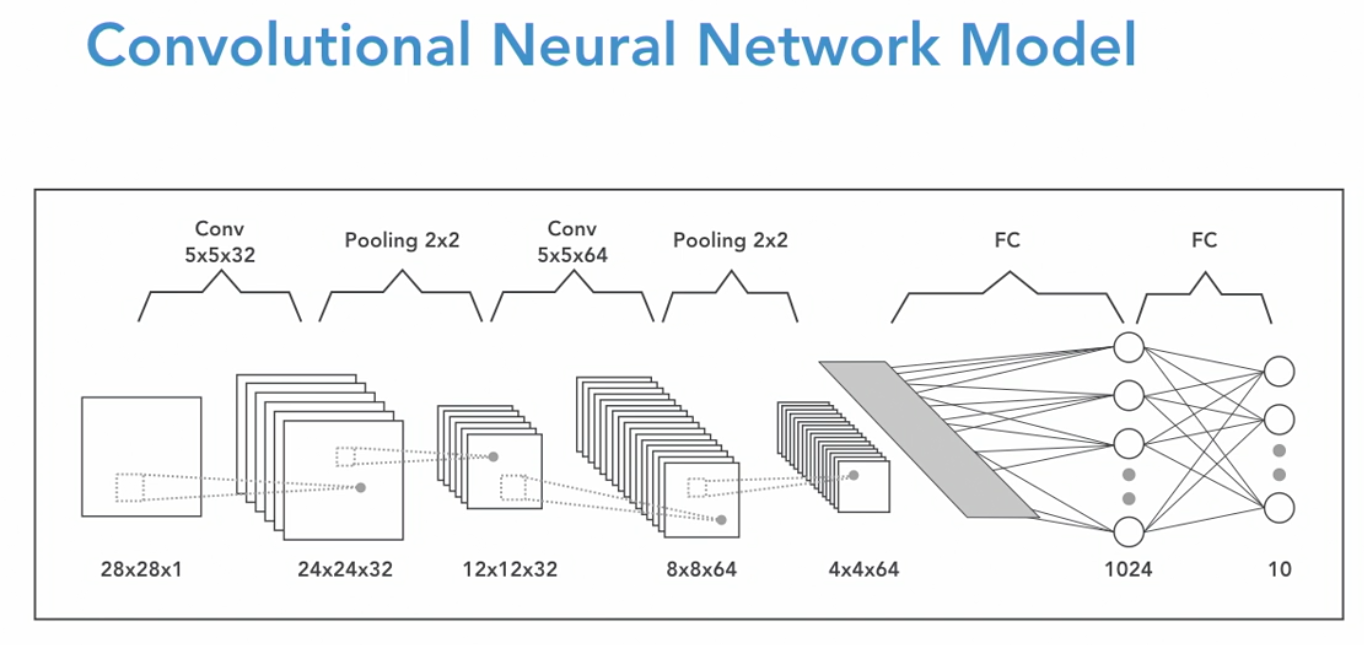

## Creating, compiling and training the model

Create the CNN as above

In [8]:
cnn = Sequential()

In [9]:
## add convolution layer
cnn.add(Conv2D(32, kernel_size=(5,5), input_shape=(28,28,1), padding='same',activation='relu'))

/Users/alexyeo/Desktop/temp/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


- 1st argument is the number of filters (32)
- 2nd argument is kernel size (5x5)
- 3rd argument is the input_shape, which corresponds to the shape of our (28x28x1 b/c it's a grayscale image).
- 4th argument is the padding ('same')
- 5th argument is activation function ('relu')
- Access documentation by pressing shift + tab this shows options available to you for hyperparamaters

In [10]:
## add next layer which is the pooling layer
cnn.add(MaxPooling2D())

In [11]:
## add 2nd convolution layer
cnn.add(Conv2D(64, kernel_size=(5,5), padding='same',activation='relu'))

- don't need to specify input_shape for 2nd convolution layer, b/c keras can infer that 

In [12]:
## add next layer which is the pooling layer
cnn.add(MaxPooling2D())

In [13]:
#flatten network b/c there's a dense and fully connected network coming next. 
cnn.add(Flatten())

In [14]:
#fully connected network
cnn.add(Dense(1024, activation='relu'))

- 1st argument is the number of nodes (1024)

In [15]:
#another fully connected layer, but this is the output layer. 
cnn.add(Dense(10, activation='softmax'))

- first argument is the number of outputs/classes/bins (10)

In [16]:
#compile the layers
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
print(cnn.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,212,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,274,634 (12.49 MB)

 Trainable params: 3,274,634 (12.49 MB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
weighter = cnn.save_weights('cnn-model5.weights.h5')

## Train the model

In [20]:
#history_cnn = cnn.fit(X_train,y_train,epochs=5,verbose=1,validation_data=(X_train,y_train))

In [21]:
#plt.plot(history_cnn.history_cnn['acc'])
#plt.plot(history_cnn.history_cnn['val_acc'])

In [19]:
cnn.load_weights('cnn-model5.weights.h5')

In [20]:
score = cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0845 - loss: 2.3069


In [21]:
print(score)

[2.3071210384368896, 0.07859999686479568]
